In [1]:
from diffusers import DiffusionPipeline
import torch
from diffusers import DiffusionPipeline
from transformers import BitsAndBytesConfig

model_name = "Qwen/Qwen-Image"

torch_dtype = torch.bfloat16
device = "cuda"

pipe = DiffusionPipeline.from_pretrained(
    model_name, 
    torch_dtype=torch_dtype,
    use_safetensors=True,
    load_in_8bit=True  # Simple 8-bit loading
    )

# pipe = pipe.to(device)
pipe.enable_model_cpu_offload()

Keyword arguments {'load_in_8bit': True} are not expected by QwenImagePipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

The config attributes {'pooled_projection_dim': 768} were passed to QwenImageTransformer2DModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Loading checkpoint shards:   0%|          | 0/9 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [2]:
from transformers import pipeline

gemma_pipe = pipeline("text-generation", model="google/gemma-3-1b-it")
messages = [
    {"role": "user", "content": "Who are you?"},
]
gemma_pipe(messages)

Device set to use cuda:0


[{'generated_text': [{'role': 'user', 'content': 'Who are you?'},
   {'role': 'assistant',
    'content': 'Hi there! I’m Gemma, a large language model created by the Gemma team at Google DeepMind. I’m an open-weights model, which means I’m publicly available for use! \n\nI can take text and images as input and generate text as output. \n\nHow can I help you today?'}]}]

In [3]:
system_prompt = """You are a helpful assistant who creates prompts for generating rendered 3D objects. Focus on: \n 
- Avoid introductory phrases and meta-commentary, only write the prompt \n
- Add typical 3D rendering elements such as: Render, high quality 3D model, neutral background, optimized for 3D printing, ZBrush digital sculpt, stylized 3D model. \n
- Think about what the user wants and describe the desired object so that the generated image can resemble the 3D model of it. 
- Consider adding something like: safe-for-work, family-friendly if necessary"""

# system_prompt = """You are a helpful assistant who creates prompts to generate images of rendered 3D objects. Avoid introductory phrases and meta-commentary."""

def create_image_prompt(start_prompt):
    """Generate a summary for a single caption using the Gemma model"""
    # Load and process the image
    
    messages = [
                {
            "role": "system",
           "content": [{"type": "text", "text": system_prompt}]
        },
    {
        "role": "user",
        "content": [

            {"type": "text", "text":"Create a prompt based on: " + start_prompt}
        ]
    }
    ]
    return messages

In [4]:
# Generate image
prompt = '''a pretzel-copter, a helicopter where the cockpit is in a pretzel shape and the whole helicopter looks like a pretzel'''
positive_magic =  ", Ultra HD, 4K, cinematic composition quality, Render, high quality 3D model, neutral background, optimized for 3D printing, ZBrush digital sculpt, stylized 3D model."
negative_prompt = "adult content, nsfw" # using an empty string if you do not have specific concept to remove

enhanced_prompt_msg = create_image_prompt(prompt)
enhanced_prompt = gemma_pipe(enhanced_prompt_msg, max_new_tokens=128)[0]['generated_text'][-1]['content']
print("Enhanced prompt: ", enhanced_prompt)

Enhanced prompt:  Render a high-quality 3D model of a pretzelcopter, stylized 3D model, neutral background, optimized for 3D printing, ZBrush digital sculpt, cockpit shaped like a pretzel, vibrant red and yellow colors, detailed metallic textures, safe-for-work, family-friendly.


  0%|          | 0/40 [00:00<?, ?it/s]

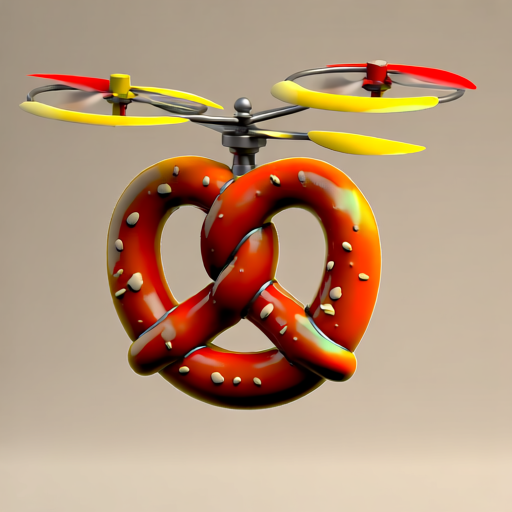

In [13]:
image = pipe(
    prompt=enhanced_prompt,
    negative_prompt=negative_prompt,
    width=512,
    height=512,
    num_inference_steps=40,
    true_cfg_scale=5.5,
    generator=torch.Generator(device="cuda").manual_seed(1337)
).images[0]
image